#  *Caracterizacion Electrica*
  

---

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import fsolve
from scipy.optimize import brentq

##Visualizacion de Curvas
y calculo de resistencias

In [2]:
def resistencia(data, condition):
  datos = pd.read_csv(data, skiprows=8)
  datos = datos.iloc[1:]

  V = datos["Reading"].values
  I = datos["Value"].values
# Regresión lineal por mínimos cuadrados: V = R * I + b
  slope, intercept, r_value, p_value, std_err = linregress(I, V)

  if condition == True:
  # Array de resistencias individuales R_i = V_i / I_i
  # Evitamos división por cero donde la corriente sea 0
    resistencias_individuales = np.divide(V, I, out=np.zeros_like(V), where=I!=0)
    return resistencias_individuales
  else:

    print(f"Resistencia calculada (R): {slope:.6f} Ohm")
    print(f"Error en la resistencia: {std_err:.6f} Ohm")

    Y = slope*I + intercept
    return  I, V , Y , slope, intercept  #corriente, voltaje, interpolacion, resistencia, intercepto


In [3]:
ancho_corto= "https://raw.githubusercontent.com/SoffMoscoso/PhysicsLabs/refs/heads/main/Advanced%20laboratory%20II/Electric%20Caracterization/anchocorto.csv"
ancho_largo1= "https://raw.githubusercontent.com/SoffMoscoso/physics-lab-experiments/refs/heads/main/ADVANCE-LAB-II/Electric%20Caracterization/ancholargo1.csv"
ancho_largo2= "https://raw.githubusercontent.com/SoffMoscoso/physics-lab-experiments/refs/heads/main/ADVANCE-LAB-II/Electric%20Caracterization/ancholargo2.csv"

In [4]:
A = resistencia(ancho_corto, False)
B = resistencia(ancho_largo1, False)
C = resistencia(ancho_largo2, False)

Resistencia calculada (R): 0.013068 Ohm
Error en la resistencia: 0.000015 Ohm
Resistencia calculada (R): 0.251494 Ohm
Error en la resistencia: 0.000016 Ohm
Resistencia calculada (R): 0.250883 Ohm
Error en la resistencia: 0.000028 Ohm


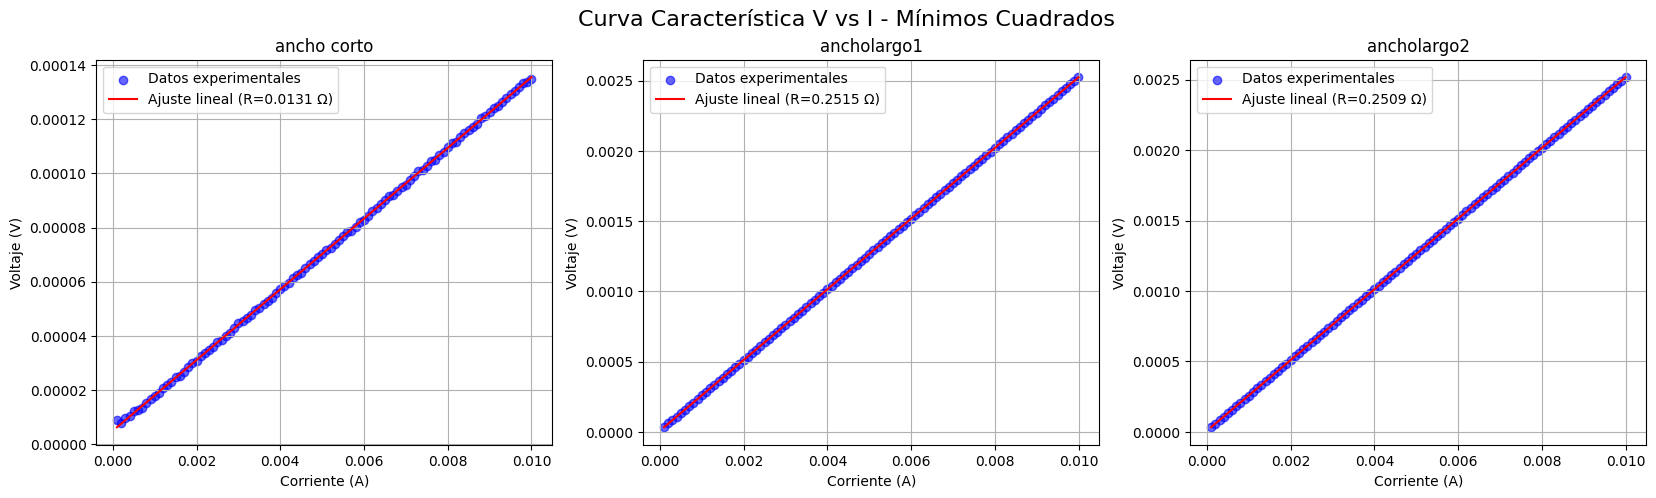

In [5]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
plt.scatter(A[0], A[1], color="blue", label="Datos experimentales", alpha=0.6)
plt.plot(A[0], A[2], color="red", label=f"Ajuste lineal (R={A[3]:.4f} Ω)")
plt.xlabel("Corriente (A)")
plt.ylabel("Voltaje (V)")
plt.title("ancho corto")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(B[0], B[1], color="blue", label="Datos experimentales", alpha=0.6)
plt.plot(B[0], B[2], color="red", label=f"Ajuste lineal (R={B[3]:.4f} Ω)")
plt.xlabel("Corriente (A)")
plt.ylabel("Voltaje (V)")
plt.title("ancholargo1")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(C[0], C[1], color="blue", label="Datos experimentales", alpha=0.6)
plt.plot(C[0], C[2], color="red", label=f"Ajuste lineal (R={C[3]:.4f} Ω)")
plt.xlabel("Corriente (A)")
plt.ylabel("Voltaje (V)")
plt.title("ancholargo2")
plt.grid(True)
plt.legend()

plt.suptitle("Curva Característica V vs I - Mínimos Cuadrados", fontsize=16)
plt.show()

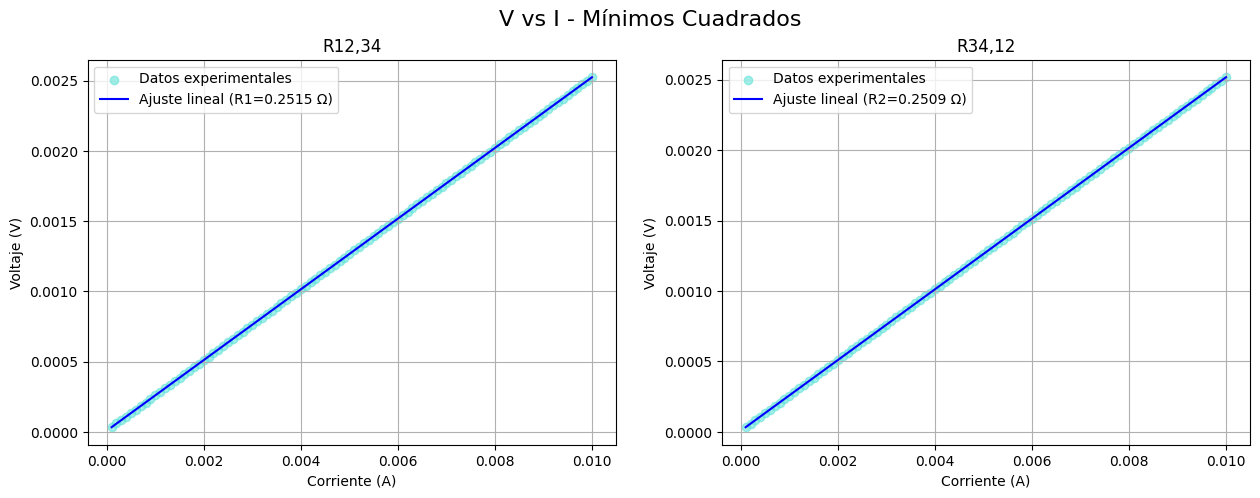

In [6]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(B[0], B[1], color="#62E3D8", label="Datos experimentales", alpha=0.6)
plt.plot(B[0], B[2], color="blue", label=f"Ajuste lineal (R1={B[3]:.4f} Ω)")
plt.xlabel("Corriente (A)")
plt.ylabel("Voltaje (V)")
plt.title("R12,34")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(C[0], C[1], color="#62E3D8", label="Datos experimentales", alpha=0.6)
plt.plot(C[0], C[2], color="blue", label=f"Ajuste lineal (R2={C[3]:.4f} Ω)")
plt.xlabel("Corriente (A)")
plt.ylabel("Voltaje (V)")
plt.title("R34,12")
plt.grid(True)
plt.legend()

plt.suptitle("V vs I - Mínimos Cuadrados", fontsize=16)
plt.show()

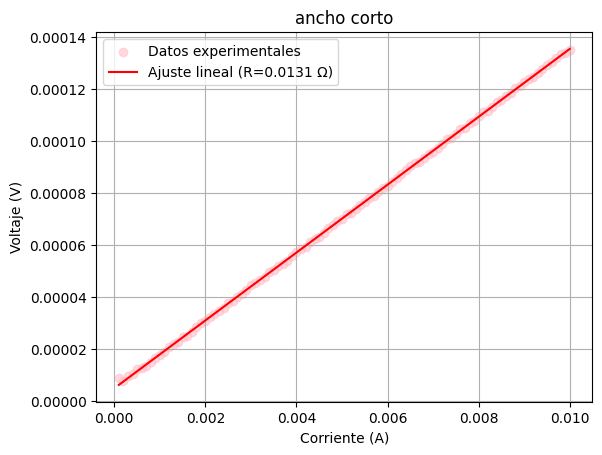

In [7]:
plt.scatter(A[0], A[1], color="pink", label="Datos experimentales", alpha=0.6)
plt.plot(A[0], A[2], color="red", label=f"Ajuste lineal (R={A[3]:.4f} Ω)")
plt.xlabel("Corriente (A)")
plt.ylabel("Voltaje (V)")
plt.title("ancho corto")
plt.grid(True)
plt.legend()

In [8]:
#El valor de r en ancho largo es el promedio de las dos
#como estas tienen diferentes valores de incertidumbre el ponderado se hace asi:

# Resistencias x1,x2 con sus incvertidumbres s1,s2
x1 = 0.251494
s1 = 0.000016

x2 = 0.250883
s2 = 0.000028

# Pesos (inverso de la varianza)
w1 = 1 / s1**2
w2 = 1 / s2**2

# Promedio ponderado
x_bar = (w1 * x1 + w2 * x2) / (w1 + w2)

# Incertidumbre del promedio
s_bar = np.sqrt(1 / (w1 + w2))

print("Promedio:", x_bar)
print("Incertidumbre:", s_bar)

Promedio: 0.2513436
Incertidumbre: 1.3891890273991348e-05


## Solucion Van der Pauw

$
\sigma_{R_s}^2 =
\left( \frac{\partial R_s}{\partial R_{\parallel}} \, \sigma_{R_{\parallel}} \right)^2
+
\left( \frac{\partial R_s}{\partial R_{\perp}} \, \sigma_{R_{\perp}} \right)^2
$

$
f(R_s) = e^{-\pi \frac{R_{\parallel}}{R_s}} + e^{-\pi \frac{R_{\perp}}{R_s}} - 1
$

In [9]:
# incertidumbres
R_par = 0.013068
R_perp = 0.251494

s_R_par = 0.000016   # ejemplo
s_R_perp = 0.000028  # ejemplo

def f(Rs, R_par, R_perp):
    return np.exp(-np.pi * R_par / Rs) + np.exp(-np.pi * R_perp / Rs) - 1

# Resolver Rs
def solve_Rs(R_par, R_perp):
    return brentq(lambda Rs: f(Rs, R_par, R_perp), 1e-6, 10)

Rs = solve_Rs(R_par, R_perp)

# Derivadas numéricas (diferencias finitas)
delta = 1e-6

dRs_dRpar = (solve_Rs(R_par + delta, R_perp) - solve_Rs(R_par - delta, R_perp)) / (2 * delta)
dRs_dRperp = (solve_Rs(R_par, R_perp + delta) - solve_Rs(R_par, R_perp - delta)) / (2 * delta)

# Propagación de incertidumbre
s_Rs = np.sqrt((dRs_dRpar * s_R_par)**2 + (dRs_dRperp * s_R_perp)**2)

print("Rs =", Rs)
print("Incertidumbre =", s_Rs)

Rs = 0.3562497845285234
Incertidumbre = 0.00013311843131642222


#Grosor Lamina

In [10]:
# Valores
p = 1.67*10e-8
Rs = 0.3562
s_Rs = 0.0001  # incertidumbre de Rs

# Valor central
grosor = p / Rs

# Propagación de incertidumbre
s_grosor = (p / Rs**2) * s_Rs

print("p/Rs =", grosor*10e6, " µm")
print("Incertidumbre =", s_grosor*10e6, " µm")

p/Rs = 4.688377316114542  µm
Incertidumbre = 0.001316220470554335  µm
